## Project Overview

This mini project analyzes inforce insurance policy data and performs a simplified cash flow projection.
The project focuses on policy status monitoring, lapse rate analysis, and a basic estimation of future premium income and expected claims

## Import Library

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Generate Synthetic Policy Data

In [17]:
np.random.seed(42)
n = 500

data = pd.DataFrame({
    "PolicyID": range(1, n+1),
    "IssueDate": pd.to_datetime(
        np.random.choice(pd.date_range("2020-01-01", "2024-01-01"), n)
    ),
    "Age": np.random.randint(25, 60, n),
    "Premium": np.random.randint(3_000_000, 12_000_000, n),
    "SumAssured": np.random.randint(100_000_000, 500_000_000, n),
    "Status": np.random.choice(
        ["Active", "Lapsed"], n, p=[0.75, 0.25]
    )
})


## Inforce Monitoring 

### Policy Status Distribution

In [19]:
status_summary = data["Status"].value_counts()
status_summary

Status
Active    383
Lapsed    117
Name: count, dtype: int64

### Lapse Rate
The lapse rate is calculated to support monthly inforce monitoring and policy status evaluation.

In [20]:
lapse_rate = (data["Status"]=="Lapsed").mean()
lapse_rate

np.float64(0.234)

## Visualization

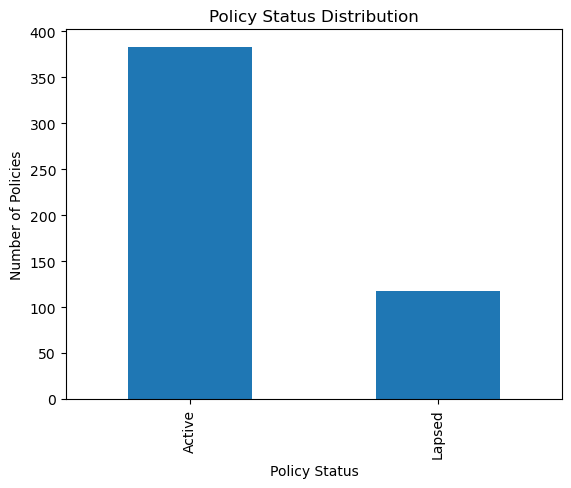

In [21]:
status_summary.plot(kind="bar", title="Policy Status Distribution")
plt.xlabel("Policy Status")
plt.ylabel("Number of Policies")
plt.show()

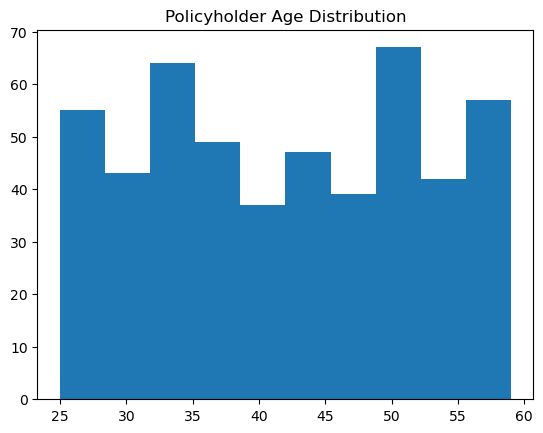

In [22]:
plt.hist(data["Age"], bins=10)
plt.title("Policyholder Age Distribution")
plt.show()

## Simplified Actuarial Projection
The following projection provides a simplified estimation of future premium income and expected claims.

### Assumptions:
Annual interest rate: 5%
Mortality rate: 0.2% per year
Projection period: 5 years
Only Active policies considered

### Premium Income Projection

In [23]:
active_policies = data[data["Status"]=="Active"]

annual_premium = active_policies["Premium"].sum()

projection = pd.DataFrame({
    "Year": range(1,6),
    "Projected_Premium": [
        annual_premium / ((1+0.05)**year) for year in range(1,6)
    ]
})
projection

,Year,Projected_Premium
0,1,2.760355e+09
1,2,2.628909e+09
2,3,2.503723e+09
3,4,2.384498e+09
4,5,2.270951e+09


### Expected Claims Estimation

In [24]:
expected_claims = (
    active_policies["SumAssured"].sum() * 0.002
)

expected_claims

np.float64(234761592.11)

### Key Insights
- The policy portfolio is dominated by **active policies (76.6%)**, indicating a relatively stable inforce base.
- The **lapse rate of 23.4%** highlights the importance of continuous monitoring, as lapses may significantly impact future premium income.
- The projected premium income shows a **gradual decline over the 5-year horizon**, mainly driven by discounting under a 5% interest rate assumption.
- Expected claims represent approximately **8–9% of total projected premium income**, providing a high-level view of portfolio risk under simplified assumptions.

## Conclusion
This project demonstrates a simplified inforce monitoring and actuarial projection process.
The analysis supports monthly reporting, policy status evaluation, and high-level estimation of future cash flows, aligned with inforce management activities.